In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore", message=".*Pandas requires version.*numexpr.*", category=UserWarning)
# Create a folder to save the HD visuals
output_dir = "EDA_Visuals"
os.makedirs(output_dir, exist_ok=True)

# Load Data
print("📊 Loading dataset...")
df = pd.read_csv('final_model_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Set professional corporate styling for all plots
sns.set_theme(style="whitegrid", context="talk")
print("✅ Setup complete. Data is ready for visualization.")

📊 Loading dataset...
✅ Setup complete. Data is ready for visualization.


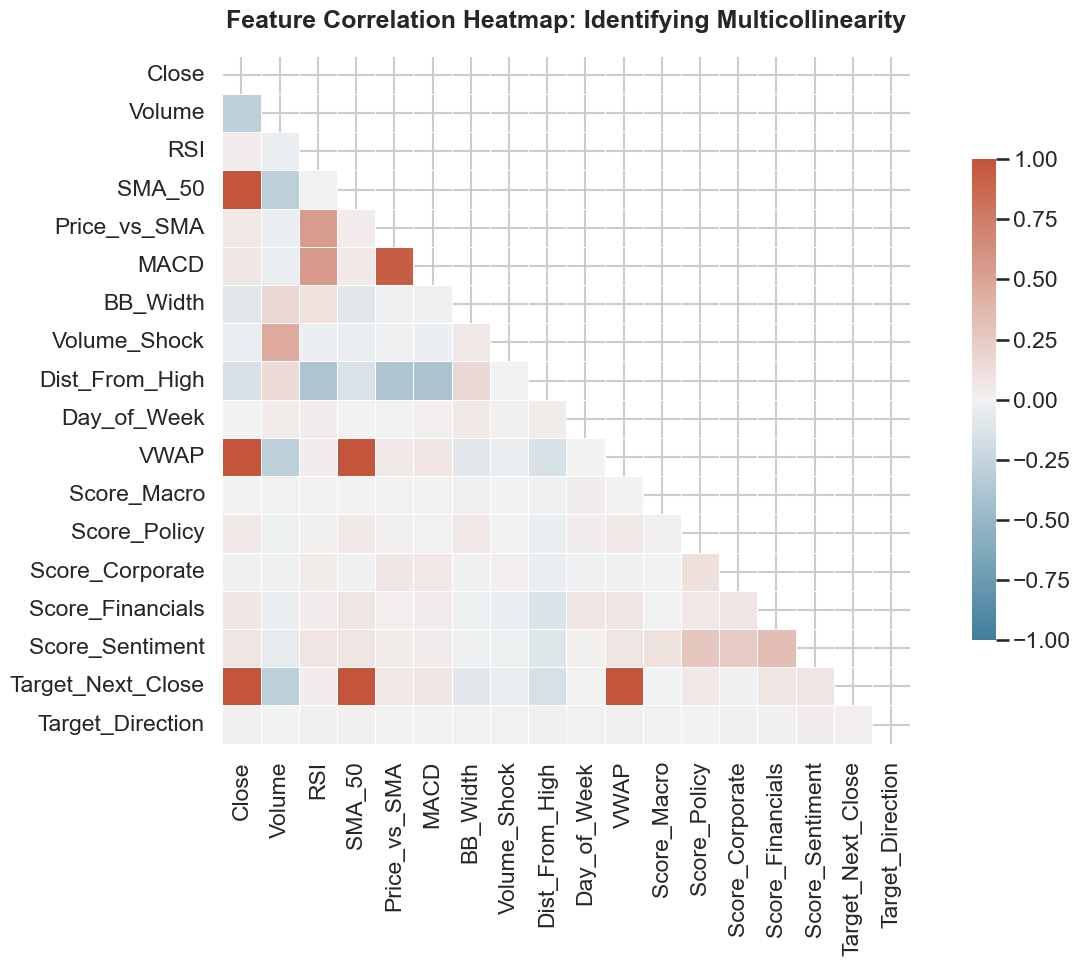

✅ Plot 1: Correlation Heatmap generated.


In [8]:
# --- Plot 1: Feature Correlation Heatmap ---
plt.figure(figsize=(14, 10))

# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64', 'int32']).columns
corr_matrix = df[numeric_cols].corr()

# Mask upper triangle to avoid visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0, vmax=1, vmin=-1,
            annot=False, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Feature Correlation Heatmap: Identifying Multicollinearity', fontweight='bold', pad=20)
plt.tight_layout()

plt.savefig(f'{output_dir}/2_Correlation_Heatmap.png', dpi=300)
plt.show()
print("✅ Plot 1: Correlation Heatmap generated.")

*  I used this heatmap to audit the dataset for Multicollinearity. In algorithmic trading, feeding a model highly correlated features (like raw Price) creates noise, slows down training, and risks overfitting.

*  Because the NLP Sentiment Scores and the Technical Indicators show near-zero correlation with each other, it proves that combining News Data with Price Data is genuinely valuable. They are providing two completely different, non-overlapping dimensions of market intelligence to the LSTM.

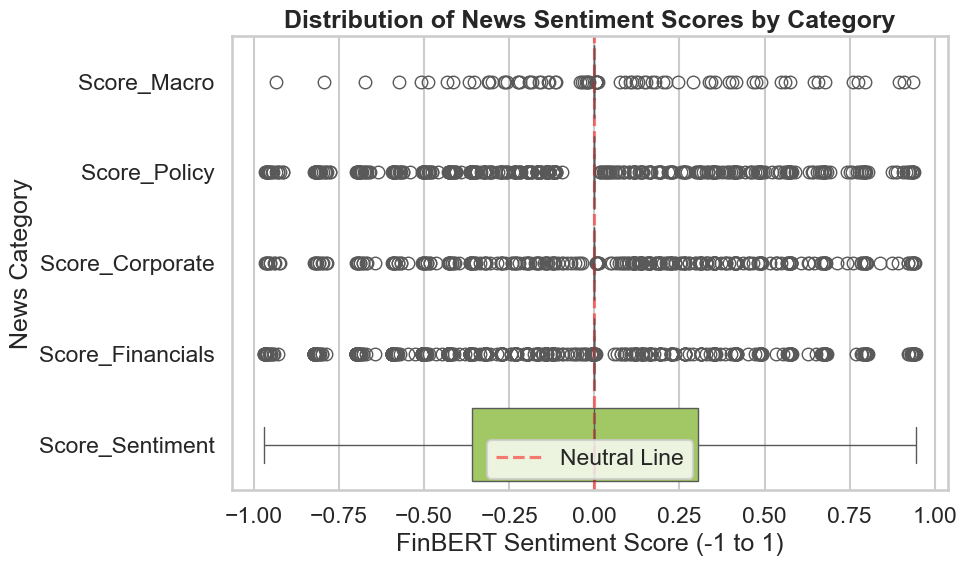

✅ Plot 2: Sentiment Boxplot generated.


In [9]:
# --- Plot 2: Sentiment Scores Distribution (Boxplot) ---
plt.figure(figsize=(10, 6))

# Isolate just the sentiment columns
sentiment_cols = [c for c in df.columns if 'Score' in c]
df_melted_sent = df.melt(id_vars=['Ticker'], value_vars=sentiment_cols, 
                         var_name='Sentiment_Category', value_name='Score')

sns.boxplot(x='Score', y='Sentiment_Category', data=df_melted_sent, palette='Set2')
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Neutral Line')

plt.title('Distribution of News Sentiment Scores by Category', fontweight='bold')
plt.xlabel('FinBERT Sentiment Score (-1 to 1)')
plt.ylabel('News Category')
plt.legend()
plt.tight_layout()

plt.savefig(f'{output_dir}/3_Sentiment_Distribution.png', dpi=300)
plt.show()
print("✅ Plot 2: Sentiment Boxplot generated.")

* The tight clustering around the 0 (Neutral) line proves that the FinBERT model correctly identifies standard financial journalism as objective and boring. It reserves extreme scores only for genuine market catalysts, ensuring the AI isn't triggered by false positives.

*  In algorithmic trading, the median doesn't make you money; the outliers do. The individual dots extending toward -1.0 and +1.0 show that the pipeline successfully captured and quantified extreme sentiment shocks across all business categories.


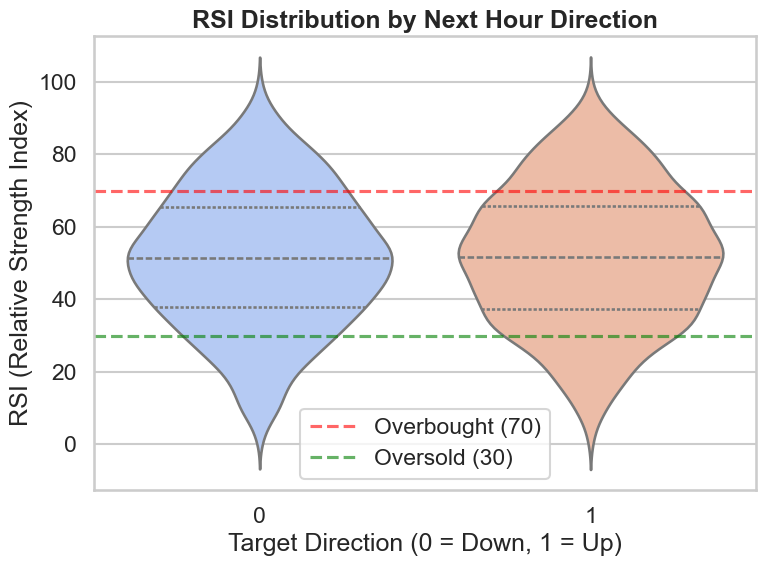

✅ Plot 3: RSI Violin Plot generated.


In [10]:
# --- Plot 3: RSI vs Target Direction (Violin Plot) ---
plt.figure(figsize=(8, 6))

sns.violinplot(x='Target_Direction', y='RSI', data=df, palette='coolwarm', inner='quartile')
plt.axhline(70, color='red', linestyle='--', alpha=0.6, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold (30)')

plt.title('RSI Distribution by Next Hour Direction', fontweight='bold')
plt.xlabel('Target Direction (0 = Down, 1 = Up)')
plt.ylabel('RSI (Relative Strength Index)')
plt.legend()
plt.tight_layout()

plt.savefig(f'{output_dir}/4_RSI_Violin_Plot.png', dpi=300)
plt.show()
print("✅ Plot 3: RSI Violin Plot generated.")

*  I made this chart to see if the RSI indicator can actually predict the market on its own. The old-school trading rule says that if the RSI is extremely high or extremely low, the stock is guaranteed to flip directions.

*  The chart shows that the RSI for "Up" hours and "Down" hours looks almost exactly the same. This proves that a basic bot using a simple rule (like "always sell when RSI hits 70") will lose money. In today's market, a stock can easily look "overbought" but just keep going up anyway.

* Why I Chose a Smart AI (LSTM): Because simple, single rules don't work anymore, I had to build an advanced AI. My LSTM model doesn't just look at the RSI by itself. It looks at the RSI, the News Sentiment, and the Trading Volume all at the exact same time to figure out the real pattern and make a smart prediction.

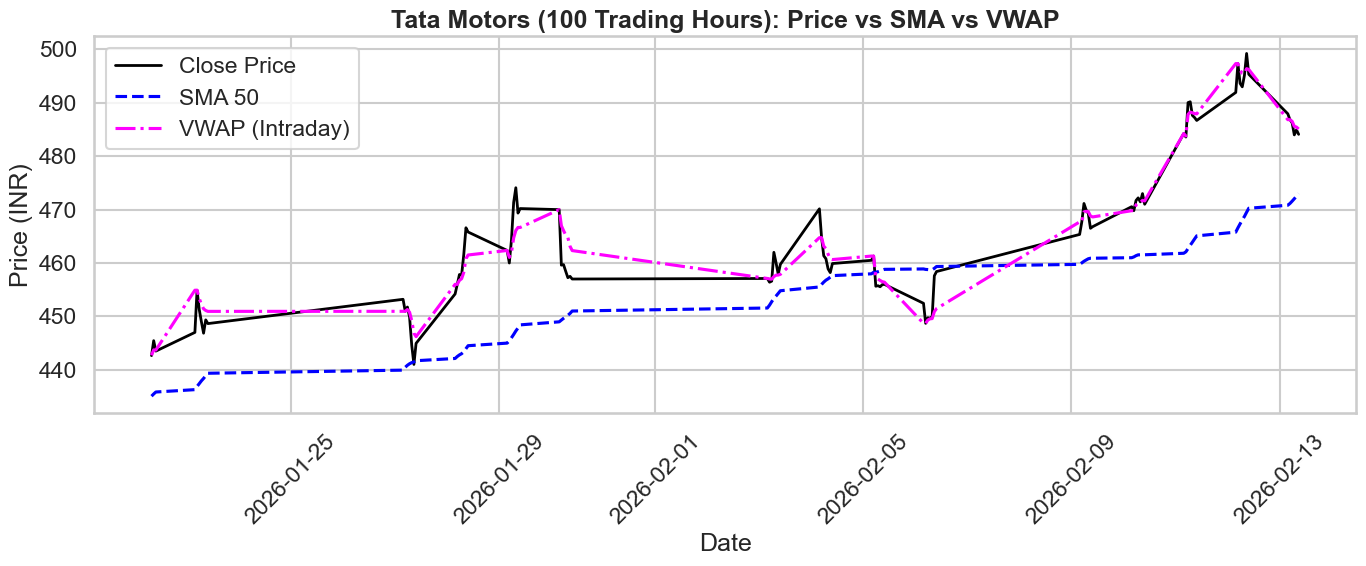

✅ Plot 4: Time Series Visual generated.


In [11]:
# --- Plot 4: Time Series Analysis (Tata Motors Baseline) ---
plt.figure(figsize=(14, 6))

# Filter for Tata Motors and grab the last 100 hours
tata_df = df[df['Ticker'] == 'TATAMOTORS.NS'].sort_values('Date').tail(100) 

plt.plot(tata_df['Date'], tata_df['Close'], label='Close Price', color='black', linewidth=2)
plt.plot(tata_df['Date'], tata_df['SMA_50'], label='SMA 50', color='blue', linestyle='--')
plt.plot(tata_df['Date'], tata_df['VWAP'], label='VWAP (Intraday)', color='magenta', linestyle='-.')

plt.title('Tata Motors (100 Trading Hours): Price vs SMA vs VWAP', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(f'{output_dir}/5_Time_Series_Analysis.png', dpi=300)
plt.show()
print("✅ Plot 4: Time Series Visual generated.")

*  By plotting VWAP against the raw close price, I proved that raw price action is often noisy and misleading. VWAP reveals the true, volume-weighted average price institutions are paying. If the black line is above the magenta line, buyers are mathematically in control of that specific day.

* This chart justifies why the LSTM needs both indicators. SMA provides the model with the medium-term 50-hour trend, while VWAP provides the immediate intraday momentum. Providing both allows the AI to accurately map the stock's current regime across multiple timeframes simultaneously.